# 77 Box datasets

Load every box dataset (gastronorm, plastic, wood, cardboard, shoebox) into one
dataframe with all per-sample metadata plus file paths to the vibration FFT and the
ground-truth segmentation image. Then, per box, compare an empty-box capture against
a capture with an object in the top-left corner (same speaker).

Set the speaker with the `SPEAKER` env var (default 1), e.g. `SPEAKER=3 jupyter ...`.

# 0 Imports & config

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 220, "display.max_columns", 80)

REPO = Path.cwd().parent
SPEAKER = int(os.environ.get("SPEAKER", "1"))
print(f"SPEAKER = {SPEAKER}  (override with the SPEAKER env var)")

# box -> samples dir
BOX_DIRS = {
    "gastronorm": REPO / "experiments/31_07_2026_gastronorm_exp1/samples",
    "plastic":    REPO / "experiments/31_08_2026_green_plastic_two_laser_faces/samples",
    "wood":       REPO / "experiments/2026_09_06_wood_box/samples",
    "cardboard":  REPO / "experiments/2026_09_07_cardboard_box/samples",
    "shoebox":    REPO / "experiments/2026_09_08_shoebox/samples",
}
for b, d in BOX_DIRS.items():
    assert d.is_dir(), f"missing {b}: {d}"

SPEAKER = 1  (override with the SPEAKER env var)


# 1 Load all datasets into one dataframe

Walk each box's `samples/` tree directly (rather than `model.dataset.collect_samples`,
which currently references an undefined `FFT_FILES`). Every sample dir contributes one
row: all keys from `metadata.jsonl`, plus resolved file paths.

File-path columns:
- `path_dir` &ndash; the sample directory
- `path_fft` &ndash; raw vibration FFT (`vibration/04_ffts.npz`, or gastronorm's `vibration/04_fft.npz`)
- `path_smask_npy` / `path_smask_png` &ndash; ground-truth segmentation mask
- `path_overhead_png` &ndash; aligned overhead photo (matches the mask)
- `path_raw_overhead_png` &ndash; raw overhead photo
- `path_smask_ds32` &ndash; 32x32 downsampled mask, when present

In [2]:
FFT_NAMES = ["vibration/04_ffts.npz", "vibration/04_fft.npz"]


def read_metadata(sample_dir: Path) -> dict:
    """metadata.jsonl is one single-key JSON object per line; merge them."""
    meta = {}
    for line in (sample_dir / "metadata.jsonl").read_text().splitlines():
        line = line.strip()
        if line:
            meta.update(json.loads(line))
    return meta


def parse_com(v):
    """avg_com is a numpy-repr string in gastronorm ('[224.5 268.3]'), a real list
    elsewhere, and '[-1 -1]' / nan / [] for empty boxes. Return [c0, c1] or None."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return None
    if isinstance(v, str):
        s = v.strip("[]").replace(",", " ").strip()
        parts = [float(x) for x in s.split()] if s else []
    elif isinstance(v, (list, tuple, np.ndarray)):
        parts = np.asarray(v, dtype=float).ravel().tolist()
    else:
        return None
    return parts[:2] if len(parts) >= 2 else None


def first_existing(sample_dir: Path, names) -> Path | None:
    for n in names:
        p = sample_dir / n
        if p.exists():
            return p
    return None


def build_box_df(box: str, samples_dir: Path) -> pd.DataFrame:
    rows = []
    for sample_dir in sorted(p for p in samples_dir.glob("*") if p.is_dir()):
        if not (sample_dir / "metadata.jsonl").exists():
            continue
        row = read_metadata(sample_dir)
        row["box_dataset"] = box                       # keep even if metadata 'box' disagrees
        row["path_dir"] = str(sample_dir)
        row["path_fft"] = _s(first_existing(sample_dir, FFT_NAMES))
        row["path_smask_npy"] = _s(first_existing(sample_dir, ["image/03_smask.npy"]))
        row["path_smask_png"] = _s(first_existing(sample_dir, ["image/03_smask.png"]))
        row["path_overhead_png"] = _s(first_existing(sample_dir, ["image/02_cropped_overhead.png"]))
        row["path_raw_overhead_png"] = _s(first_existing(sample_dir, ["image/01_raw_overhead.png"]))
        row["path_smask_ds32"] = _s(first_existing(sample_dir, ["image/04_downsampled_smask_32h_32w.npy"]))
        com = parse_com(row.get("avg_com"))
        row["com0"], row["com1"] = (com if com else (np.nan, np.nan))
        rows.append(row)
    df = pd.DataFrame(rows)
    # sample_id / position_id as integers, not zero-padded strings
    df["sample_id"] = pd.to_numeric(df["sample_id"], errors="coerce").astype("Int64")
    df["position_id"] = pd.to_numeric(df["position_id"], errors="coerce").astype("Int64")
    return df.sort_values("sample_id").reset_index(drop=True)


def _s(p):
    return str(p) if p is not None else None

In [3]:
df = pd.concat([build_box_df(b, d) for b, d in BOX_DIRS.items()], ignore_index=True)

# tidy dtypes for the columns we filter on
df["is_empty_box"] = df["is_empty_box"].fillna(False).astype(bool)
df["n_objects"] = pd.to_numeric(df["n_objects"], errors="coerce").fillna(0).astype(int)

print(f"{len(df)} samples total, {df.shape[1]} columns")
print(df.groupby("box_dataset").agg(
    n=("sample_id", "size"),
    empty=("is_empty_box", "sum"),
    with_fft=("path_fft", lambda s: s.notna().sum()),
    speakers=("speaker", lambda s: sorted(s.dropna().unique().tolist())),
))

6583 samples total, 47 columns
                n  empty  with_fft                  speakers
box_dataset                                                 
cardboard     492     20       492              [1, 2, 3, 4]
gastronorm   3008     56      3007  [1, 2, 3, 4, 5, 6, 7, 8]
plastic       615     20       615              [1, 3, 5, 7]
shoebox      1524     55      1524              [1, 3, 5, 7]
wood          944     20       944              [1, 3, 5, 7]


In [4]:
df.head()

,sample_id,position_id,speaker,experiment_dir,timestamp,box,n_objects,objects,layout,description,is_empty_box,audio_dir,audio_fs,min_freq,max_freq,prompts,seg_results,coms,avg_com,segment_scale,height,width,n_frames,n_capture_seconds,fps,expose,gain,buffer_part_count,power,n_rows,n_cols,rois,run_opt,run_opt_multiROIs,pclk_batch_size,use_PC,laser_idx,box_dataset,path_dir,path_fft,path_smask_npy,path_smask_png,path_overhead_png,path_raw_overhead_png,path_smask_ds32,com0,com1
0,9,2,1,D:\eturok\31_07_2026_gastronorm_exp1,2026-07-31T09:28:32.596144+00:00,gastronorm,0,{},empty-box,An empty open gastronorm box from a bird's eye...,True,C:\Users\eitanturok\good-vibrations\data\audio...,44100,50,1000,[],[],"[[[-1, -1]]]",[-1 -1],1.0,300,1024,3250,1.3,2500,60,1,1625,440.9,10,10,"[[28, 0, 70, 30], [129, 0, 70, 30], [227, 0, 7...","{'cam_params': {'camera_FPS': 2500, 'exposure'...","{'N_ROIs': 10, 'ROI_height': 30, 'total_image_...",256,False,55,gastronorm,/home/ethantu/workspace/good-vibrations/experi...,NaN,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,NaN,-1.0,-1.0
1,10,2,2,D:\eturok\31_07_2026_gastronorm_exp1,2026-07-31T09:28:34.484136+00:00,gastronorm,0,{},empty-box,An empty open gastronorm box from a bird's eye...,True,C:\Users\eitanturok\good-vibrations\data\audio...,44100,50,1000,[],[],"[[[-1, -1]]]",[-1 -1],1.0,300,1024,3250,1.3,2500,60,1,1625,440.9,10,10,"[[28, 0, 70, 30], [129, 0, 70, 30], [227, 0, 7...","{'cam_params': {'camera_FPS': 2500, 'exposure'...","{'N_ROIs': 10, 'ROI_height': 30, 'total_image_...",256,False,55,gastronorm,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,-1.0,-1.0
2,11,2,3,D:\eturok\31_07_2026_gastronorm_exp1,2026-07-31T09:28:36.032258+00:00,gastronorm,0,{},empty-box,An empty open gastronorm box from a bird's eye...,True,C:\Users\eitanturok\good-vibrations\data\audio...,44100,50,1000,[],[],"[[[-1, -1]]]",[-1 -1],1.0,300,1024,3250,1.3,2500,60,1,1625,440.9,10,10,"[[28, 0, 70, 30], [129, 0, 70, 30], [227, 0, 7...","{'cam_params': {'camera_FPS': 2500, 'exposure'...","{'N_ROIs': 10, 'ROI_height': 30, 'total_image_...",256,False,55,gastronorm,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,-1.0,-1.0
3,12,2,4,D:\eturok\31_07_2026_gastronorm_exp1,2026-07-31T09:28:37.605673+00:00,gastronorm,0,{},empty-box,An empty open gastronorm box from a bird's eye...,True,C:\Users\eitanturok\good-vibrations\data\audio...,44100,50,1000,[],[],"[[[-1, -1]]]",[-1 -1],1.0,300,1024,3250,1.3,2500,60,1,1625,440.9,10,10,"[[28, 0, 70, 30], [129, 0, 70, 30], [227, 0, 7...","{'cam_params': {'camera_FPS': 2500, 'exposure'...","{'N_ROIs': 10, 'ROI_height': 30, 'total_image_...",256,False,55,gastronorm,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...,-1.0,-1.0
4,13,2,5,D:\eturok\31_07_2026_gastronorm_exp1,2026-07-31T09:28:39.231801+00:00,gastronorm,0,{},empty-box,An empty open gastronorm box from a bird's eye...,True,C:\Users\eitanturok\good-vibrations\data\audio...,44100,50,1000,[],[],"[[[-1, -1]]]",[-

In [5]:
# every column in the combined dataframe
list(df.columns)

['sample_id',
 'position_id',
 'speaker',
 'experiment_dir',
 'timestamp',
 'box',
 'n_objects',
 'objects',
 'layout',
 'description',
 'is_empty_box',
 'audio_dir',
 'audio_fs',
 'min_freq',
 'max_freq',
 'prompts',
 'seg_results',
 'coms',
 'avg_com',
 'segment_scale',
 'height',
 'width',
 'n_frames',
 'n_capture_seconds',
 'fps',
 'expose',
 'gain',
 'buffer_part_count',
 'power',
 'n_rows',
 'n_cols',
 'rois',
 'run_opt',
 'run_opt_multiROIs',
 'pclk_batch_size',
 'use_PC',
 'laser_idx',
 'box_dataset',
 'path_dir',
 'path_fft',
 'path_smask_npy',
 'path_smask_png',
 'path_overhead_png',
 'path_raw_overhead_png',
 'path_smask_ds32',
 'com0',
 'com1']

# 2 Per-box: empty box vs object in the top-left corner

For each box we take two captures at `SPEAKER`:
1. an **empty box**, and
2. the capture whose object center-of-mass is nearest the top-left corner
   (smallest `com0 + com1`).

Left column: the two overhead photos (empty on top). Right column, top: the average
`|FFT|` magnitude spectrum of each, overlaid (mean over lasers and x/y channels).
Right column, bottom: their difference, object &minus; empty box.

In [6]:
def avg_fft_mag(fft_path: str):
    """Mean |FFT| over all lasers and both channels -> (freqs, mag) of shape (F,)."""
    with np.load(fft_path) as z:
        fft, freqs = z["fft"], z["freqs"]
    mag = np.abs(fft[0]).mean(axis=(0, 2))          # (1,L,F,C) -> (F,)
    return freqs, mag


def pick_pair(df: pd.DataFrame, box: str, speaker: int):
    """(empty_row, topleft_row) for `box`. Falls back to any speaker if the requested
    one has no empty / no object capture, and says so."""
    b = df[df["box_dataset"] == box]

    def by_speaker(sub, what):
        s = sub[sub["speaker"] == speaker]
        if len(s):
            return s, speaker
        print(f"  [{box}] no {what} for speaker {speaker}; using any speaker")
        return sub, None

    empty, _ = by_speaker(b[b["is_empty_box"] & b["path_fft"].notna()], "empty box")
    empty_row = empty.iloc[0]

    obj = b[(~b["is_empty_box"]) & (b["n_objects"] >= 1) & b["com0"].notna() & b["path_fft"].notna()]
    obj, _ = by_speaker(obj, "object capture")
    single = obj[obj["n_objects"] == 1]          # prefer a single object so the com is one point
    obj = single if len(single) else obj
    topleft_row = obj.loc[(obj["com0"] + obj["com1"]).idxmin()]
    return empty_row, topleft_row


def describe(row) -> str:
    com = "" if pd.isna(row["com0"]) else f", com=({row['com0']:.0f}, {row['com1']:.0f})"
    return (f"{row['box_dataset']} #{row['sample_id']}  spk {row['speaker']}  "
            f"{row.get('layout', '?')}{com}")


def plot_box(box: str, speaker: int = SPEAKER):
    empty_row, obj_row = pick_pair(df, box, speaker)
    fe, me = avg_fft_mag(empty_row["path_fft"])
    fo, mo = avg_fft_mag(obj_row["path_fft"])
    assert np.allclose(fe, fo), "freq grids differ"
    diff = mo - me

    fig = plt.figure(figsize=(16, 7), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.7])
    ax_e = fig.add_subplot(gs[0, 0])
    ax_o = fig.add_subplot(gs[1, 0])
    ax_fft = fig.add_subplot(gs[0, 1])
    ax_diff = fig.add_subplot(gs[1, 1], sharex=ax_fft)

    for ax, row, tag in [(ax_e, empty_row, "empty box"), (ax_o, obj_row, "top-left object")]:
        ax.imshow(plt.imread(row["path_overhead_png"]))
        ax.set_title(f"{tag}\n{describe(row)}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    ax_fft.plot(fe, me, lw=0.8, label="empty box", color="#888")
    ax_fft.plot(fo, mo, lw=0.8, label="top-left object", color="#4b6bfb")
    ax_fft.set_title(f"{box}: average |FFT| magnitude (mean over lasers & x/y), speaker {speaker}", fontsize=10)
    ax_fft.set_ylabel("mean |FFT|")
    ax_fft.legend(fontsize=8)
    ax_fft.tick_params(labelbottom=False)

    ax_diff.axhline(0, color="#bbb", lw=0.8)
    ax_diff.plot(fe, diff, lw=0.8, color="#d9730d")
    ax_diff.set_title("difference: object − empty box", fontsize=10)
    ax_diff.set_xlabel("frequency (Hz)")
    ax_diff.set_ylabel("Δ mean |FFT|")

    plt.show()
    return empty_row, obj_row

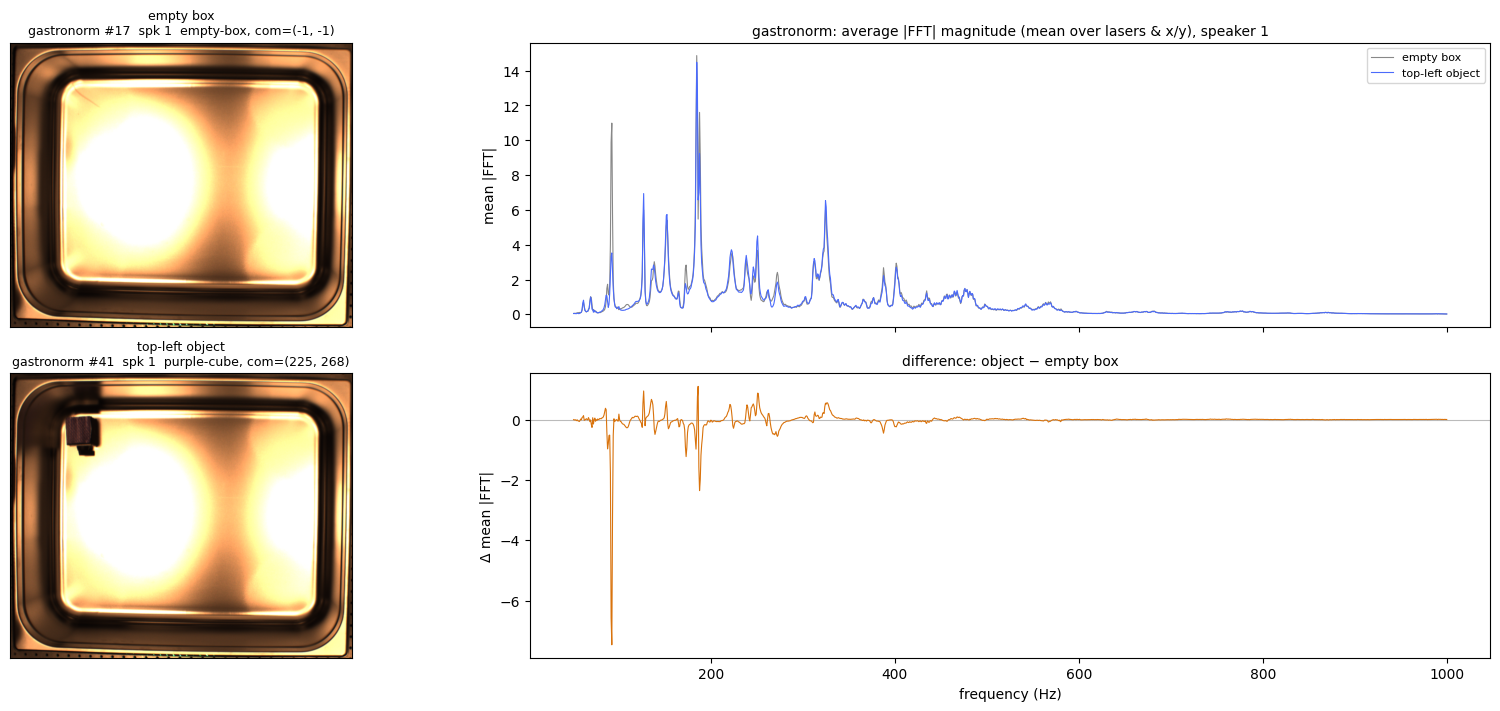

(sample_id                                                               17
 position_id                                                              3
 speaker                                                                  1
 experiment_dir                        D:\eturok\31_07_2026_gastronorm_exp1
 timestamp                                 2026-07-31T09:28:48.309523+00:00
 box                                                             gastronorm
 n_objects                                                                0
 objects                                                                 {}
 layout                                                           empty-box
 description              An empty open gastronorm box from a bird's eye...
 is_empty_box                                                          True
 audio_dir                C:\Users\eitanturok\good-vibrations\data\audio...
 audio_fs                                                             44100
 min_freq   

In [7]:
plot_box("gastronorm")

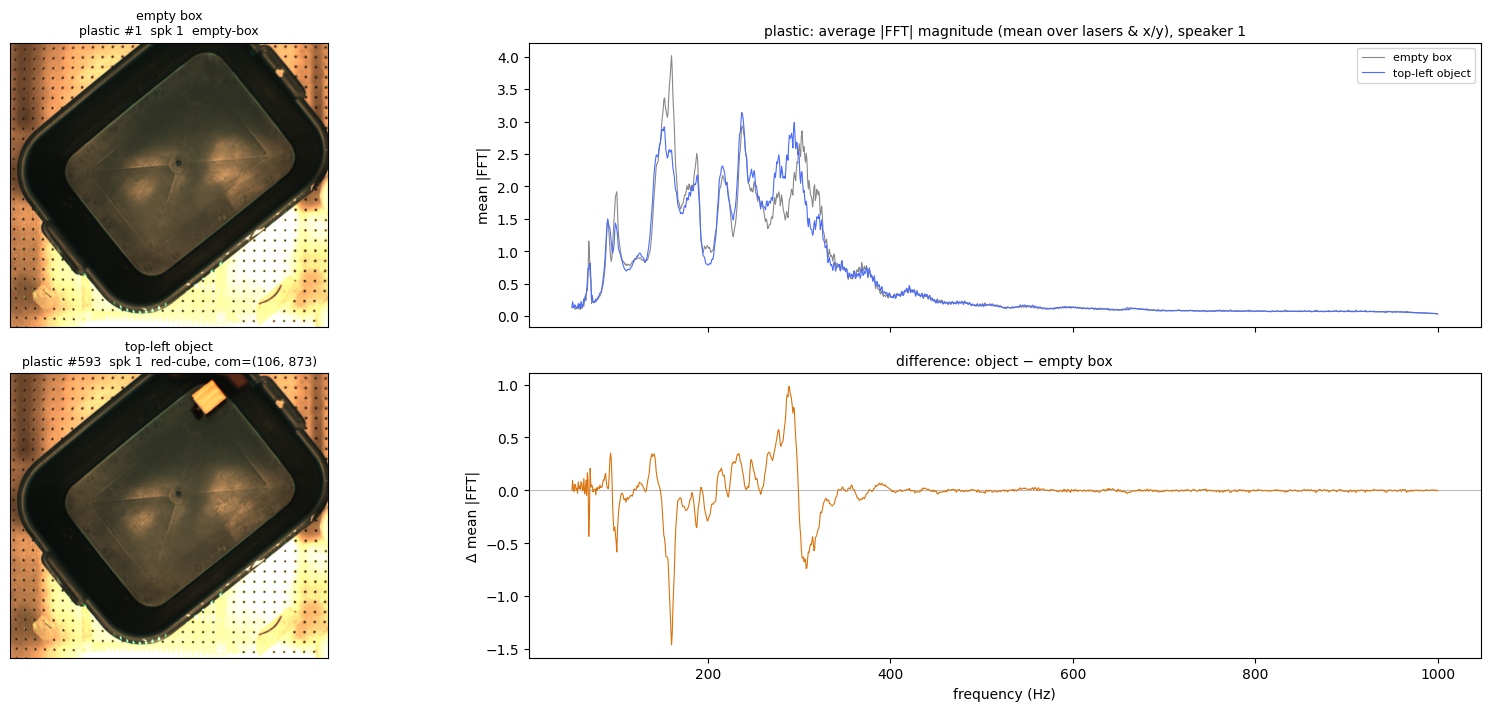

(sample_id                                                                1
 position_id                                                              0
 speaker                                                                  1
 experiment_dir           D:\eturok\31_08_2026_green_plastic_two_laser_f...
 timestamp                                 2026-08-31T13:55:13.477517+00:00
 box                                                          green-plastic
 n_objects                                                                0
 objects                                                                 {}
 layout                                                           empty-box
 description              An empty open green-plastic box from a bird's ...
 is_empty_box                                                          True
 audio_dir                C:\Users\eitanturok\good-vibrations\data\audio...
 audio_fs                                                             44100
 min_freq   

In [8]:
plot_box("plastic")

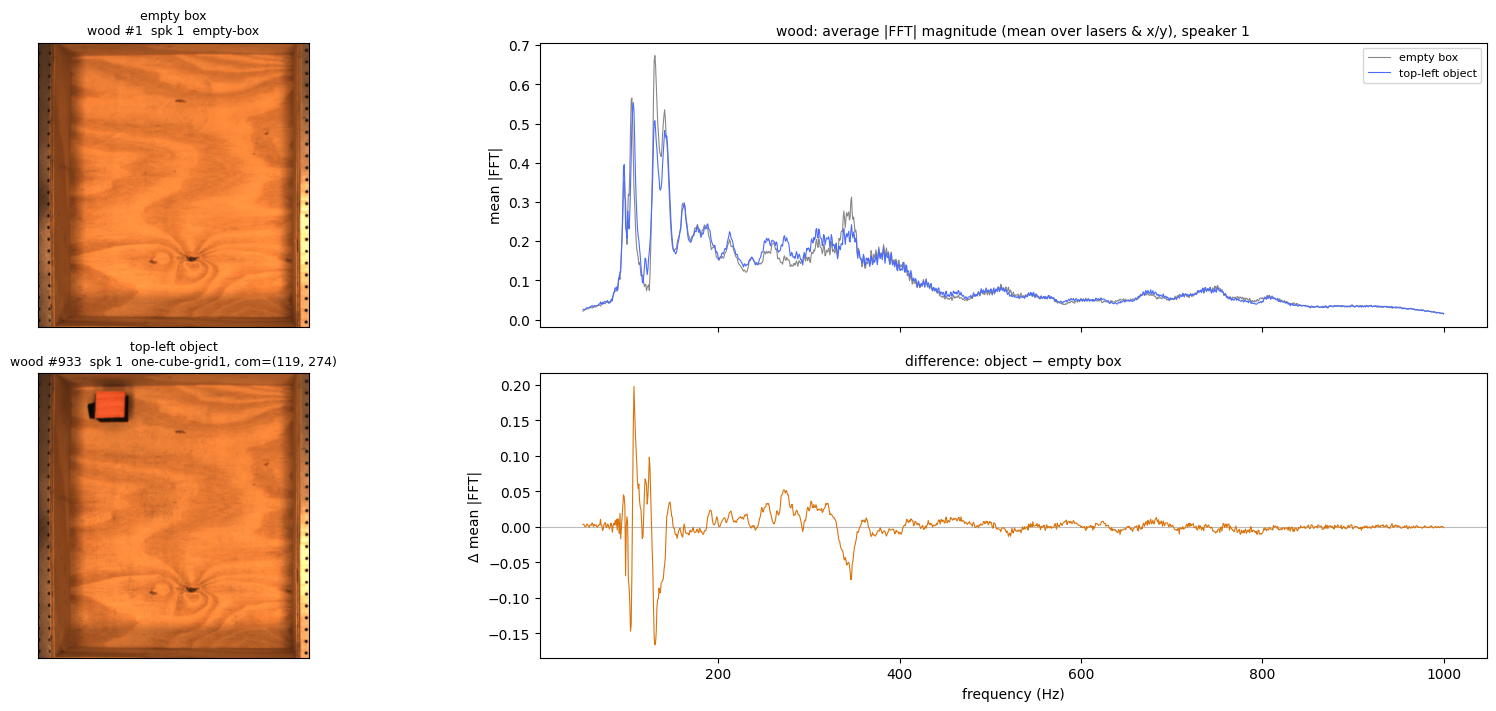

(sample_id                                                                1
 position_id                                                              1
 speaker                                                                  1
 experiment_dir                               D:\eturok\2026_09_06_wood_box
 timestamp                                 2026-09-06T15:43:30.998403+00:00
 box                                                                   wood
 n_objects                                                                0
 objects                                                                 {}
 layout                                                           empty-box
 description                 An empty open wood box from a bird's eye view.
 is_empty_box                                                          True
 audio_dir                C:\Users\eitanturok\good-vibrations\data\audio...
 audio_fs                                                             44100
 min_freq   

In [9]:
plot_box("wood")

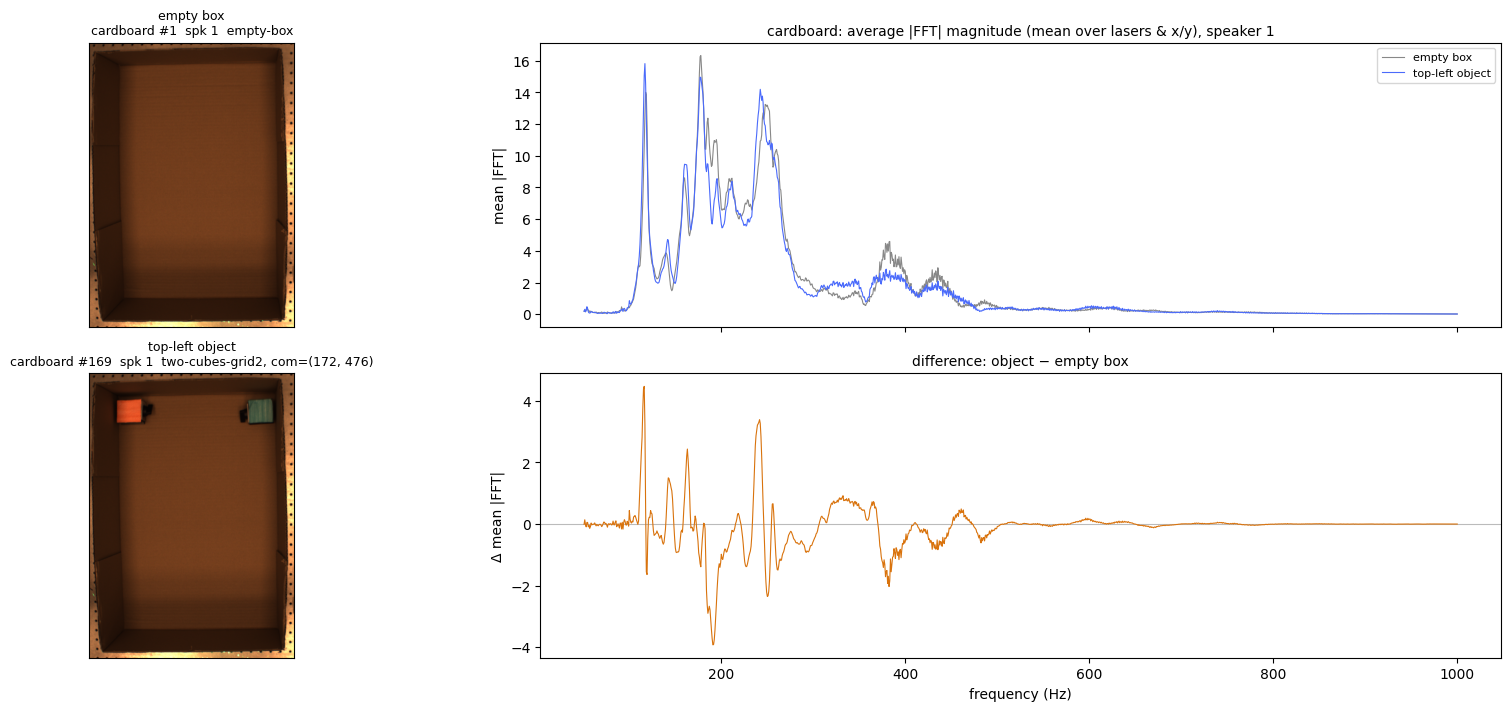

(sample_id                                                                1
 position_id                                                              1
 speaker                                                                  1
 experiment_dir                          D:\eturok\2026_09_07_cardboard_box
 timestamp                                 2026-09-07T17:42:14.235963+00:00
 box                                                              cardboard
 n_objects                                                                0
 objects                                                                 {}
 layout                                                           empty-box
 description                 An empty cardboard box from a bird's eye view.
 is_empty_box                                                          True
 audio_dir                C:\Users\eitanturok\good-vibrations\data\audio...
 audio_fs                                                             44100
 min_freq   

In [10]:
plot_box("cardboard")

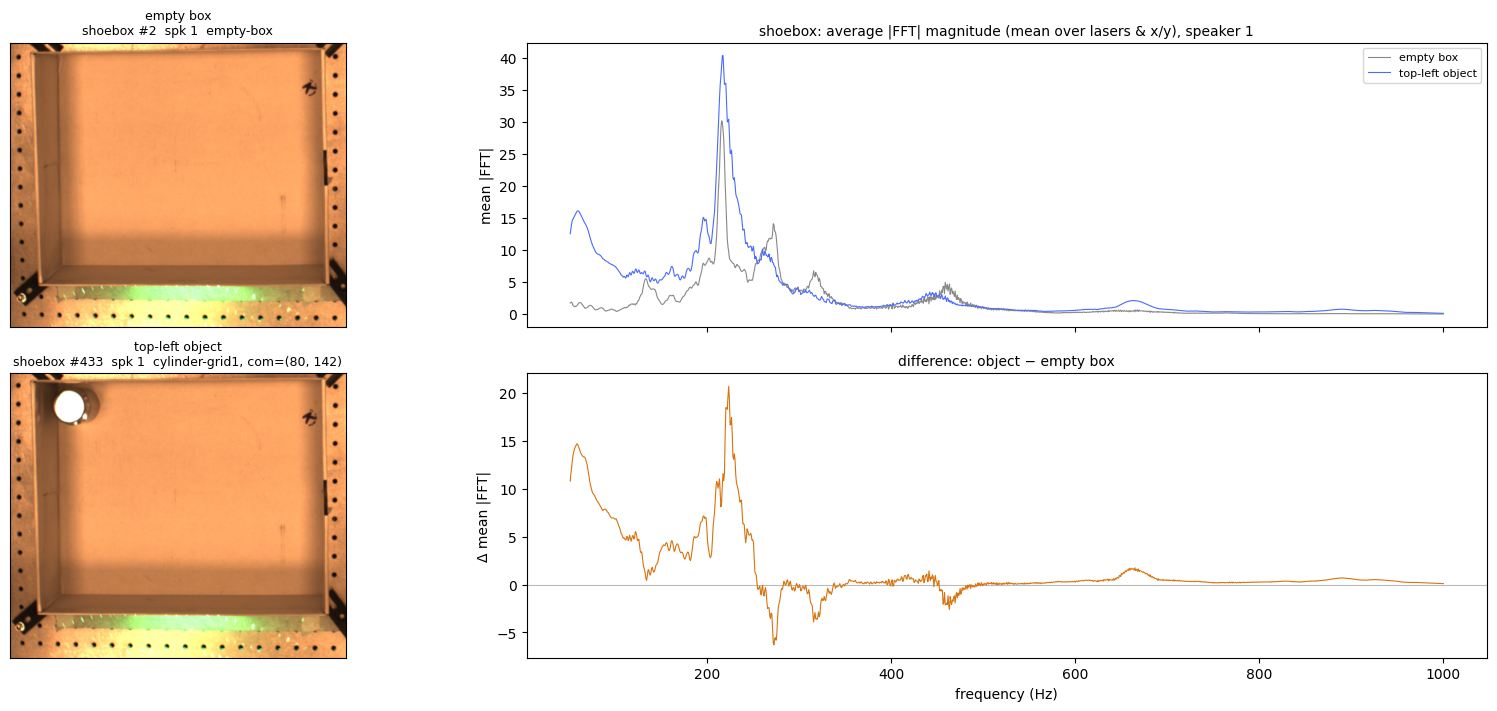

(sample_id                                                                2
 position_id                                                              1
 speaker                                                                  1
 experiment_dir                                D:\eturok\2026_09_08_shoebox
 timestamp                                 2026-09-08T12:42:23.819008+00:00
 box                                                                shoebox
 n_objects                                                                0
 objects                                                                 {}
 layout                                                           empty-box
 description                   An empty shoebox box from a bird's eye view.
 is_empty_box                                                          True
 audio_dir                C:\Users\eitanturok\good-vibrations\data\audio...
 audio_fs                                                             44100
 min_freq   

In [11]:
plot_box("shoebox")

# 3 Soft-IoU per object — the `boombox-boxes-v1` per-box runs

The `boombox-boxes-v1` sweep trained one `boombox` model per box
(`bb-boxes-{gastro,plastic,wood,cardboard,shoebox}-v1`, 1000 ep, 32×32 output). Here
we read each run's saved epoch-1000 predictions straight from
`runs/<run>/outputs_history/{train,eval/<split>}/ep1000-*.pt`, score them against the
on-disk 32×32 ground-truth masks with `utils.metrics.soft_iou` (the exact training
metric), and report the **per-object soft-IoU** on the held-out eval splits. One
colour per box.

(We don't go through `viz.data.load_run` here — its GT layout detection only knows
gastronorm/experiment-25, so wood/cardboard/shoebox raise. Reading the `.pt` files
directly needs no layout registry.)

Under each x-axis label: how many samples of that object are in **train** vs **test**
(`tr / te`), counted from the runs' own `train/` and `eval/` prediction dirs. The
legend names the wandb run for each box. Leaked-by-design `*-speaker` eval splits
(same object, positions seen in training) are dropped — they're an eval protocol, not
a distinct object.

In [12]:
import re
import sys

for _p in (str(REPO), str(REPO / "src")):     # so `utils` (repo root) imports
    if _p not in sys.path:
        sys.path.insert(0, _p)

import torch
from utils.metrics import soft_iou

BB_RUNS = {                                   # box -> run directory under runs/
    "gastronorm": "bb-boxes-gastro-v2",
    "plastic":    "bb-boxes-plastic-v2",
    "wood":       "bb-boxes-wood-v2",
    "cardboard":  "bb-boxes-cardboard-v2",
    "shoebox":    "bb-boxes-shoebox-v2",
}
RUNS_DIR = REPO / "runs"
GT32_NAME = "image/04_downsampled_smask_32h_32w.npy"


def _object_type(layout) -> str:
    """`layout` minus its -gridN / _gridN placement suffix (two-cubes-grid1 -> two-cubes)."""
    return re.sub(r"[-_]?grid\d+.*$", "", str(layout))


def _epoch_of(p) -> int:
    return int(p.stem.split("-")[0].removeprefix("ep"))


def _split_dirs(run: str):
    oh = RUNS_DIR / run / "outputs_history"
    out = [("train", oh / "train")] if (oh / "train").is_dir() else []
    ev = oh / "eval"
    if ev.is_dir():
        out += [(d.name, d) for d in sorted(ev.iterdir()) if d.is_dir()]
    return out


def _load_split_preds(split_dir):
    """(sample_ids, mask_pred) for the newest saved epoch in a split dir, deduped
    (last write per sample wins). mask_pred is (N, 32, 32) sigmoid probs."""
    files = sorted(split_dir.glob("ep*.pt"))
    if not files:
        return None
    last = max(_epoch_of(f) for f in files)
    ids, preds = [], []
    for f in sorted(x for x in files if _epoch_of(x) == last):
        o = torch.load(f, map_location="cpu", weights_only=False)
        ids.append(o["info"]["sample_id"].to(torch.int64).numpy())
        preds.append(o["mask_pred"].float().numpy())
    sids = np.concatenate(ids)
    preds = np.concatenate(preds).astype(np.float32)
    _, first = np.unique(sids[::-1], return_index=True)          # keep last occurrence
    keep = np.zeros(len(sids), bool); keep[len(sids) - 1 - first] = True
    return sids[keep], preds[keep], last


def _load_gt32(samples_dir):
    return {int(f.parent.parent.name): np.load(f).astype(np.float32)
            for f in samples_dir.glob(f"*/{GT32_NAME}")}


recs = []                                     # long: one row per (box, split, sample)
bb_meta = {}
for box, run in BB_RUNS.items():
    if not (RUNS_DIR / run).is_dir():
        print(f"  !! {box}: runs/{run} missing"); continue
    gt = _load_gt32(BOX_DIRS[box])
    epochs = set()
    for split, d in _split_dirs(run):
        got = _load_split_preds(d)
        if got is None:
            continue
        sids, preds, ep = got
        epochs.add(ep)
        has_gt = np.array([int(s) in gt for s in sids])
        sids, preds = sids[has_gt], preds[has_gt]
        if split == "train":                                    # counted, not scored
            iou = np.full(len(sids), np.nan)
        else:
            tgt = np.stack([gt[int(s)] for s in sids])
            iou = soft_iou(torch.from_numpy(preds), torch.from_numpy(tgt)).numpy()
        recs += [dict(box=box, split=split, sample_id=int(s), iou=float(v))
                 for s, v in zip(sids, iou)]
    bb_meta[box] = dict(run=run, epoch=max(epochs) if epochs else None)
    ev = sorted({r["split"] for r in recs if r["box"] == box and r["split"] != "train"})
    n = sum(1 for r in recs if r["box"] == box)
    print(f"  {box:11s} [{run}] ep {bb_meta[box]['epoch']}  {n} scored rows | eval splits: {ev}")

bb_rows = pd.DataFrame(recs)

  gastronorm  [bb-boxes-gastro-v2] ep 1000  2959 scored rows | eval splits: ['1-cube', '1-cube-speaker', '2-cubes', '2-cubes-speaker', '3-cubes', 'red-cube']
  plastic     [bb-boxes-plastic-v2] ep 1000  615 scored rows | eval splits: ['1-cube', '2-cubes']
  wood        [bb-boxes-wood-v2] ep 1000  944 scored rows | eval splits: ['1-cube', '2-cubes']
  cardboard   [bb-boxes-cardboard-v2] ep 1000  492 scored rows | eval splits: ['2-cubes']
  shoebox     [bb-boxes-shoebox-v2] ep 1000  1510 scored rows | eval splits: ['cube', 'cylinder', 'mug', 'ood-cube-clampless', 'ood-cylinder-clampless', 'ood-sneaker', 'ring']


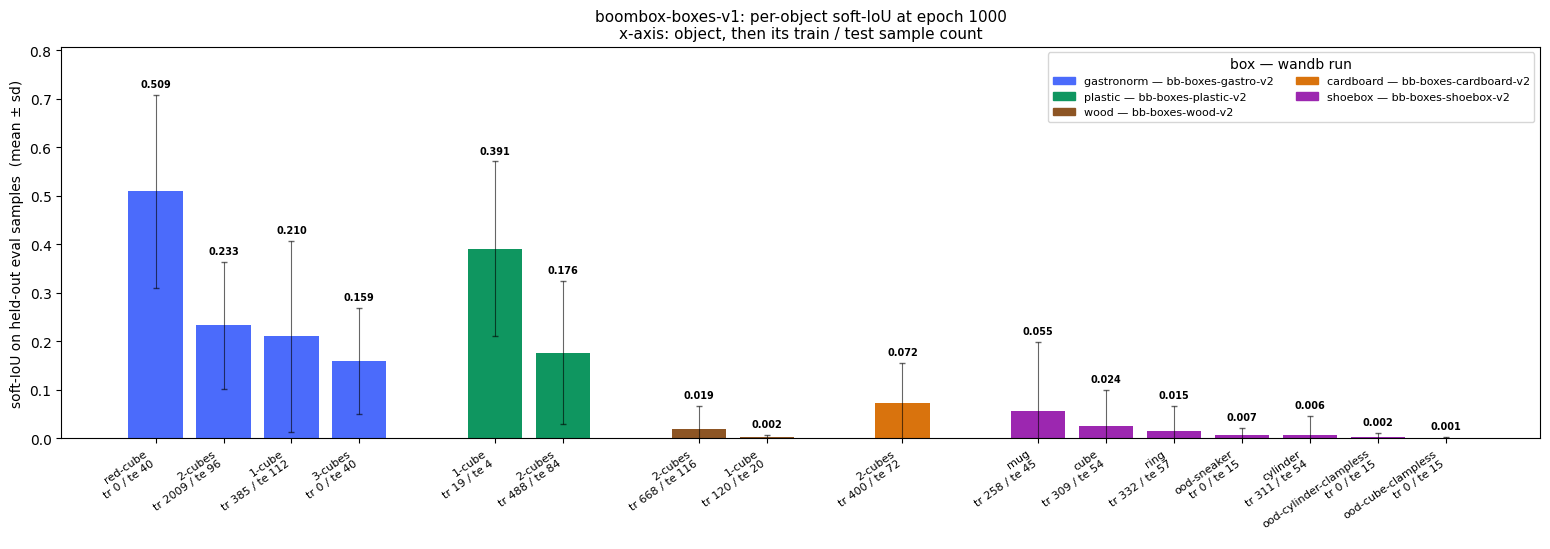

,box,object,n_test,n_train,mean_iou,std_iou
0,gastronorm,red-cube,40,0,0.508655,0.198524
1,gastronorm,2-cubes,96,2009,0.232765,0.130640
2,gastronorm,1-cube,112,385,0.210275,0.197228
3,gastronorm,3-cubes,40,0,0.159059,0.110139
4,plastic,1-cube,4,19,0.390798,0.179979
5,plastic,2-cubes,84,488,0.176357,0.147591
6,wood,2-cubes,116,668,0.018701,0.047747
7,wood,1-cube,20,120,0.001980,0.005038
8,cardboard,2-cubes,72,400,0.072431,0.082312
9,shoebox,mug,45,258,0.055439,0.142897


In [13]:
EXCLUDE_SUFFIX = "-speaker"        # leaked-by-design splits: same object, train positions

# object type per scored sample, from the Section-1 metadata (keyed by box + sample_id)
_lay = (df.dropna(subset=["sample_id"]).astype({"sample_id": "int64"})
        .set_index(["box_dataset", "sample_id"])["layout"])
bb_rows["object_type"] = [
    _object_type(_lay.get((b, s))) if (b, s) in _lay.index else None
    for b, s in zip(bb_rows["box"], bb_rows["sample_id"])
]

rows = []
for box, g in bb_rows.groupby("box"):
    train_ot = g.loc[g["split"] == "train", "object_type"]
    for s, gs in g[g["split"] != "train"].groupby("split"):
        if s.endswith(EXCLUDE_SUFFIX):
            continue
        objs = [o for o in gs["object_type"].dropna().unique()]
        n_train = int(train_ot.isin(objs).sum()) if objs else 0
        rows.append(dict(box=box, object=s, n_test=len(gs), n_train=n_train,
                         mean_iou=float(gs["iou"].mean()), std_iou=float(gs["iou"].std(ddof=0))))

bb_scores = pd.DataFrame(rows)

BOX_ORDER = ["gastronorm", "plastic", "wood", "cardboard", "shoebox"]
BOX_COLOR = {"gastronorm": "#4b6bfb", "plastic": "#0f9660", "wood": "#8d5524",
             "cardboard": "#d9730d", "shoebox": "#9c27b0"}
bb_scores["box"] = pd.Categorical(bb_scores["box"], BOX_ORDER, ordered=True)
bb_scores = bb_scores.sort_values(["box", "mean_iou"], ascending=[True, False]).reset_index(drop=True)

# x positions: a gap between boxes
x, xt, cur, gap = [], [], 0.0, 0
for _, r in bb_scores.iterrows():
    if xt and r["box"] != bb_scores.loc[xt[-1], "box"]:
        cur += 1.0
    x.append(cur); xt.append(_); cur += 1.0
x = np.array(x)

top = float((bb_scores["mean_iou"] + bb_scores["std_iou"]).max()) + 0.10

fig, ax = plt.subplots(figsize=(max(10, 0.85 * len(bb_scores) + 2), 5.6))
ax.bar(x, bb_scores["mean_iou"], yerr=bb_scores["std_iou"], width=0.8,
       color=[BOX_COLOR[b] for b in bb_scores["box"]], capsize=2, error_kw=dict(lw=0.8, alpha=0.6))
for xi, r in zip(x, bb_scores.itertuples()):
    ax.text(xi, min(r.mean_iou + r.std_iou + 0.012, top - 0.03), f"{r.mean_iou:.3f}",
            ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([f"{r.object}\ntr {r.n_train} / te {r.n_test}" for r in bb_scores.itertuples()],
                   rotation=35, ha="right", fontsize=8)
ax.set_ylim(0, top)
ax.set_ylabel("soft-IoU on held-out eval samples  (mean ± sd)")
ax.set_title("boombox-boxes-v1: per-object soft-IoU at epoch 1000\n"
             "x-axis: object, then its train / test sample count", fontsize=11)
_present = [b for b in BOX_ORDER if b in set(bb_scores["box"])]
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=BOX_COLOR[b]) for b in _present],
          labels=[f"{b} — {bb_meta[b]['run']}" for b in _present],
          fontsize=8, ncol=2, loc="upper right", title="box — wandb run")
fig.tight_layout()
plt.show()
bb_scores

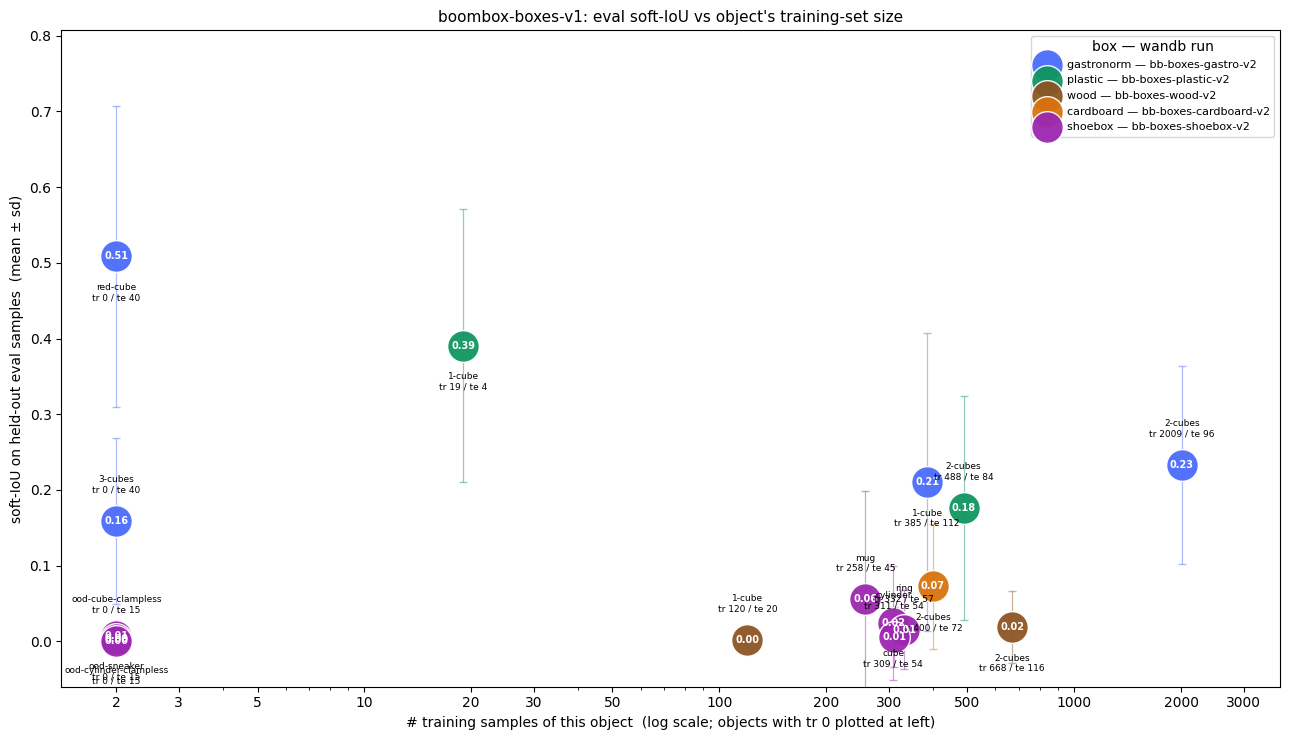

In [14]:
# eval soft-IoU vs how many training samples that object had, coloured by box
from matplotlib.ticker import LogLocator, FuncFormatter, NullFormatter

_present = [b for b in BOX_ORDER if b in set(bb_scores["box"])]
X0 = 2.0                                          # log axis: where "tr 0" objects land
nt = bb_scores["n_train"].to_numpy(float)
xs = np.where(nt > 0, nt, X0)
iou = bb_scores["mean_iou"].to_numpy(float)
sd = bb_scores["std_iou"].to_numpy(float)

fig, ax = plt.subplots(figsize=(13, 7.5))
for b in _present:
    m = (bb_scores["box"] == b).to_numpy()
    ax.errorbar(xs[m], iou[m], yerr=sd[m], fmt="none", ecolor=BOX_COLOR[b],
                elinewidth=0.9, capsize=3, alpha=0.45, zorder=1)
    ax.scatter(xs[m], iou[m], s=520, color=BOX_COLOR[b], alpha=0.95, zorder=2,
               edgecolors="white", linewidths=1.0, label=f"{b} — {bb_meta[b]['run']}")

# alternate the object label above / below the marker so neighbours don't collide
for i, (r, xv) in enumerate(zip(bb_scores.itertuples(), xs)):
    ax.annotate(f"{r.mean_iou:.2f}", (xv, r.mean_iou), ha="center", va="center",
                fontsize=7, fontweight="bold", color="white", zorder=4)
    below = i % 2 == 0
    ax.annotate(f"{r.object}\ntr {r.n_train} / te {r.n_test}", (xv, r.mean_iou),
                xytext=(0, -19 if below else 19), textcoords="offset points",
                ha="center", va="top" if below else "bottom", fontsize=6.5, zorder=4)

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 3, 5), numticks=20))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=tuple(np.arange(2, 10)), numticks=100))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlim(1.4, 3800)
ax.set_ylim(-0.06, float((iou + sd).max()) + 0.10)
ax.set_xlabel("# training samples of this object  (log scale; objects with tr 0 plotted at left)")
ax.set_ylabel("soft-IoU on held-out eval samples  (mean ± sd)")
ax.set_title("boombox-boxes-v1: eval soft-IoU vs object's training-set size", fontsize=11)
ax.legend(fontsize=8, title="box — wandb run", loc="upper right")
fig.tight_layout()
plt.show()

### Reading this

These are epoch-1000 held-out scores and they match each run's own `logs-rank0.txt`
(e.g. `bb-boxes-wood-v1` logs `eval/1-cube/iou: 0.0034`, `eval/2-cubes/iou: 0.0082`).

- **gastronorm** and **plastic** are the only two boxes whose per-box model learned a
  usable object mask.
- **`red-cube` = 0.51 on `tr 0`** — checked against `dataset.gastronorm()`: `train`
  holds only `empty-box`, `purple-cube`, `purple--green-cube-grid1..4`, `x/y-shift`;
  `eval/red-cube` is *every* `layout=='red-cube'` sample (40, all 8 speakers,
  5 positions 351–355, none shared with `purple-cube`). So the 0 is real. It still
  scores high because the model input is the **vibration FFT**, where a red cube is
  acoustically the *same object* as the `purple-cube` it trained on ~450× (same size,
  mass, contact) — colour is invisible to it. It also beats `eval/1-cube` (0.17,
  held-out purple-cube positions) partly because it's a small 5-position set with the
  highest spread (sd 0.22), so the mean rides on which 5 spots were captured, whereas
  `eval/1-cube` spans ~14 positions across the whole raster including under-trained
  corners (the "under-painting on unseen positions" failure).
- **wood, cardboard, shoebox** per-box models effectively **collapsed** — eval
  soft-IoU 0.00–0.07 across every object. Note these three have the least training
  data (492–1524 samples), the newest / hardest grid-holdout splits, and are exactly
  the boxes whose object footprint was weakest and most diffuse in Section 4
  (shoebox ratio ≈ 1.0, i.e. objects barely separable from empty-box noise). So the
  divergence metric and the trained-model IoU tell a consistent story: a weak,
  noise-level acoustic footprint → the model has nothing reliable to fit.
- `tr 0` objects (`red-cube`, `3-cubes`, all `ood-*`) are held out entirely — their
  bar is pure generalization to an unseen object.
- **The IoU-vs-training-size scatter** shows there is *no* within-reach relationship
  between how many samples of an object the model trained on and how well it scores:
  `plastic/1-cube` (19 train) beats every gastronorm object, and `wood/2-cubes`
  (668 train) scores ~0. Box identity — i.e. the strength of that box's acoustic
  object footprint — dominates over per-object dataset size.

# 4 How different is "object present" from "empty box", per box and per object?

**Goal:** a model that segments objects from the vibration spectrum can only work if
placing an object produces a change in the spectrum that is (a) large relative to
capture noise and (b) consistent across samples. If that change is small or erratic
for a given box, training on that box will underperform. This section quantifies that
change for every box, using **speaker 1 only** (set `SPEAKER` below), comparing each
object capture against the mean **empty-box** capture.

**Per object type, not just per box.** The scenes in a box are different object
configurations — `one-cube`, `two-cubes`, `ring`, `cylinder`, `mug`, … (the `layout`
with its `-gridN` suffix stripped). Each is its own thing acoustically, so we group by
object type and score every group with ≥ `MIN_GROUP` speaker-1 samples separately
against the shared empty-box reference.

## What does "different" mean here? Three candidates

We have, per capture, a complex FFT of shape `(L, F, C)` = (lasers, freq bins, x/y).
Naively subtracting the raw complex tensors and averaging over everything is a bad
idea for two reasons: **(1)** the FFT *phase* is dominated by trigger / sub-sample
timing jitter (a group-delay ramp), so two identical captures already differ hugely
in complex space — see the preprocessing notes ("log-mag > mag", "phase via group
delay is real but redundant"). **(2)** averaging over all ~100 lasers *before*
comparing dilutes a localized object's footprint by ~1/L. So: work in
**log-magnitude**, keep the **full `(L, F, C)` tensor**, and only collapse to a
scalar at the very end.

| # | Metric | Procedure | Pros | Cons |
|---|--------|-----------|------|------|
| **A** | **RMS Δ log-magnitude** | `S = log|FFT|`; footprint `D = S − mean(S_empty)`; distance = `sqrt(mean(D²))` over `(L,F,C)` (optionally top-k lasers) | dead simple; interpretable ("mean dB change"); same domain the model consumes | conflates real signal with noise; sensitive to per-box vibration amplitude and to the log noise-floor; says nothing about whether the change is *learnable* vs random |
| **B** | **1 − cosine similarity** of the spectra | flatten each capture, `1 − cos(S_sample, S_empty)` | scale-invariant → comparable across boxes with different absolute amplitude; measures *reshaping* of the spectrum, robust to gain drift | blind to pure amplitude changes (a uniform attenuation is a real, detectable cue but scores ~0); dominated by the big shared box resonances, so dynamic range is tiny; hard to interpret |
| **C** | **Noise-normalized effect size** (discriminability) | estimate per-bin capture noise `σ` from the empty-box replicates; `Z = (S_sample − mean(S_empty)) / σ`; report `RMS(Z)` and `frac(|Z|>2)`; headline = **ratio** `RMS(Z)_object / RMS(Z)_held-out-empty` (how many times harder an object pushes the spectrum than re-recording an empty box does) | directly answers the goal — it *is* the SNR the model must exploit; normalizes out **both** each box's amplitude **and** its noisiness; the ratio is bias-matched (object and empty go through the identical estimator) so it stays comparable across boxes; `frac(|Z|>2)` says how much of the spectrum carries the cue | needs replicate empties for the noise estimate (only 5–15 per box → σ is rough; mitigated with a robust MAD estimator, a floor, and bootstrapping a fixed number of empties); full multivariate Mahalanobis is infeasible at `L·F·C ≈ 2·10⁵` dims, so we use the per-bin diagonal version |

## Choice: **C**, with **A** reported alongside as the literal "how big is the change"

C is the one tied to *why training differs across boxes*: model trainability ≈ how
separable object-present is from object-absent given the noise. The headline number is
the **RMS(Z) ratio** (object vs held-out empty) plus **`frac(|Z|>2)`**; both put
every box's object footprint on the same "units of this box's own capture noise"
scale. A is kept as a sanity companion (the raw magnitude of the change); where A and
C disagree on the ranking, that gap is itself informative (big raw change but low
ratio ⇒ a loud but noisy box). B is not used — its scale-invariance is appealing but
it throws away the amplitude cue and has almost no dynamic range on this data.

**High-energy-band variant.** Alongside the full-spectrum score we recompute C on
only the **top `HI_ENERGY_FRAC` of frequency bins by empty-box energy** (the dominant
box resonances). If the object cue lives in/near resonances, the high-band ratio is
*higher* than the full-band one and a model could get away with a narrow input; if
it's *lower*, the discriminative information is spread through the quiet bins and
band-limiting the input would hurt.

Confounds this does **not** control for (keep in mind when linking to model metrics):
frequency resolution, laser-grid size, GT-mask resolution vs the 32×32 output,
number of distinct positions, and box size.

In [15]:
# ---- Section 4 config -------------------------------------------------
import re

SPEAKER = int(os.environ.get("SPEAKER", "1"))     # speaker to analyse (env-overridable)
MIN_GROUP = 20                                     # min speaker-1 samples for an object type to be scored
SIG_Z = 2.0                                        # |Z| threshold for a "significantly perturbed" bin
N_REF_EMPTY = 5                                    # empties per noise estimate (equalised across boxes)
B_BOOT = 8                                         # bootstrap draws of N_REF_EMPTY empties (boxes with more)
HI_ENERGY_FRAC = 0.10                              # keep this top fraction of freq bins by empty-box energy
RNG = np.random.default_rng(0)
print(f"Section 4: SPEAKER={SPEAKER}  MIN_GROUP={MIN_GROUP}  N_REF_EMPTY={N_REF_EMPTY}  "
      f"B_BOOT={B_BOOT}  HI_ENERGY_FRAC={HI_ENERGY_FRAC}")


def load_logmag(fft_path: str) -> np.ndarray:
    """log|FFT| as float32 (L, F, C). Magnitude floored at its 1st percentile so
    near-zero bins don't blow up the log."""
    with np.load(fft_path) as z:
        mag = np.abs(z["fft"][0]).astype(np.float32)      # (1,L,F,C) -> (L,F,C)
    floor = np.percentile(mag, 1)
    return np.log(np.maximum(mag, floor))


def object_type(layout) -> str:
    """`layout` with the -gridN / _gridN placement suffix removed: two-cubes-grid1 -> two-cubes."""
    return re.sub(r"[-_]?grid\d+.*$", "", str(layout))


def object_groups(box: str):
    """[(object_type, sub_df), ...] for SPEAKER in `box`, groups with >= MIN_GROUP samples,
    largest first. Plus the box's empty-box dataframe."""
    b = df[(df["box_dataset"] == box) & (df["speaker"] == SPEAKER) & df["path_fft"].notna()]
    empty = b[b["is_empty_box"]]
    objs = b[~b["is_empty_box"]].copy()
    objs["object_type"] = objs["layout"].map(object_type)
    groups = [(name, g) for name, g in objs.groupby("object_type") if len(g) >= MIN_GROUP]
    groups.sort(key=lambda kv: -len(kv[1]))
    return groups, empty


def _ref_stats(E_ref: np.ndarray):
    """mean + robust (MAD) sd with a per-box floor, from a stack of empty log-mags."""
    mu = E_ref.mean(0)
    mad = np.median(np.abs(E_ref - np.median(E_ref, axis=0)), axis=0)
    sigma = np.maximum(1.4826 * mad, np.median(1.4826 * mad) + 1e-6)
    return mu, sigma


def _rms_over(z, mask=None):
    """RMS of z over (laser, freq, x/y); if mask (F,) given, only those freq bins."""
    zz = z if mask is None else z[:, :, mask, :]
    return np.sqrt(np.mean(zz ** 2, axis=(1, 2, 3)))


def _frac_over(z, mask=None):
    zz = z if mask is None else z[:, :, mask, :]
    return np.mean(np.abs(zz) > SIG_Z, axis=(1, 2, 3))


def box_divergence(box: str, plot: bool = True) -> list[dict]:
    """Object-vs-empty spectral divergence for SPEAKER, metric C, one row per object type.

    Z = (log|FFT| - mu_empty) / sigma_empty per (laser, freq, x/y) bin. mu/sigma come
    from a reference set of exactly N_REF_EMPTY empties (bootstrapped B_BOOT times when
    more exist, so every box's noise estimate has the same sample size / bias). For each
    (bootstrap x leave-one-out) reference we score every object capture -> RMS(Z),
    frac(|Z|>SIG_Z), and the held-out empty -> RMS(Z). Reported per object type:
      rmsz_ratio  = mean RMS(Z)_object / mean RMS(Z)_held-out-empty   (full spectrum)
      ratio_hi    = same, restricted to the top HI_ENERGY_FRAC freq bins by empty energy
      frac_sig / frac_sig_hi, and mean_rawA (metric A, un-normalised RMS d log-mag).
    """
    groups, empty_df = object_groups(box)
    if len(empty_df) < N_REF_EMPTY or not groups:
        print(f"  [{box}] nothing to score (empty={len(empty_df)}, groups={len(groups)})")
        return []

    E = np.stack([load_logmag(p) for p in empty_df["path_fft"]])   # (Ne, L, F, C)
    Ne = len(E)

    # top-energy frequency bins, from the empty-box mean magnitude
    energy_f = (np.exp(E.mean(0)) ** 2).sum(axis=(0, 2))           # (F,)
    k = max(1, int(round(HI_ENERGY_FRAC * energy_f.size)))
    hi_mask = np.zeros(energy_f.size, dtype=bool)
    hi_mask[np.argsort(energy_f)[-k:]] = True

    ref_sets = ([RNG.choice(Ne, N_REF_EMPTY, replace=False) for _ in range(B_BOOT)]
                if Ne > N_REF_EMPTY else [np.arange(Ne)])
    refs = []                                                      # list of (mu, sigma, held_out_empty)
    for sel in ref_sets:
        Esel = E[sel]
        for j in range(len(sel)):
            keep = np.delete(np.arange(len(sel)), j)
            mu, sigma = _ref_stats(Esel[keep])
            refs.append((mu, sigma, Esel[j]))

    emp_rmsz = np.array([_rms_over(((ho - mu) / sig)[None])[0] for mu, sig, ho in refs])
    emp_rmsz_hi = np.array([_rms_over(((ho - mu) / sig)[None], hi_mask)[0] for mu, sig, ho in refs])

    out, plot_rows = [], []
    for name, g in groups:
        O = np.stack([load_logmag(p) for p in g["path_fft"]])     # (No, L, F, C)
        rmsz = np.zeros(len(O)); frac = np.zeros(len(O)); rawA = np.zeros(len(O))
        rmsz_hi = np.zeros(len(O)); frac_hi = np.zeros(len(O))
        for mu, sigma, _ in refs:
            z = (O - mu) / sigma
            rmsz += _rms_over(z);          frac += _frac_over(z)
            rmsz_hi += _rms_over(z, hi_mask); frac_hi += _frac_over(z, hi_mask)
            rawA += _rms_over(O - mu)
        for a in (rmsz, frac, rawA, rmsz_hi, frac_hi): a /= len(refs)

        row = dict(box=box, object=name, n_objects=int(g["n_objects"].mode().iat[0]),
                   n_samples=len(g), n_empty=Ne,
                   rmsz_ratio=float(rmsz.mean() / emp_rmsz.mean()),
                   ratio_hi=float(rmsz_hi.mean() / emp_rmsz_hi.mean()),
                   frac_sig=float(frac.mean()), frac_sig_hi=float(frac_hi.mean()),
                   mean_rawA=float(rawA.mean()),
                   empty_rmsZ=float(emp_rmsz.mean()), mean_rmsZ=float(rmsz.mean()))
        out.append(row)
        plot_rows.append((name, rmsz))
        print(f"  [{box}/{name}] {len(g)}x ({row['n_objects']}-obj) vs {Ne} empty  |  "
              f"ratio={row['rmsz_ratio']:.2f}  hi-band={row['ratio_hi']:.2f}  "
              f"frac>2s={row['frac_sig']:.0%}  rawA={row['mean_rawA']:.3f}")

    if plot:
        fig, ax = plt.subplots(figsize=(7, 3.4))
        ax.violinplot([r for _, r in plot_rows], showmeans=True)
        ax.plot(range(1, len(plot_rows) + 1), [emp_rmsz.mean()] * len(plot_rows), "D",
                color="#d9730d", ms=6, label=f"held-out empty ({emp_rmsz.mean():.2f})")
        ax.set_xticks(range(1, len(plot_rows) + 1))
        ax.set_xticklabels([f"{n}\nn={len(r)}" for n, r in plot_rows], fontsize=9)
        ax.set_ylabel("RMS(Z) per capture")
        ax.set_title(f"{box}: object-vs-empty divergence by object type, speaker {SPEAKER}", fontsize=10)
        ax.legend(fontsize=8)
        fig.tight_layout()
        plt.show()
    return out

Section 4: SPEAKER=1  MIN_GROUP=20  N_REF_EMPTY=5  B_BOOT=8  HI_ENERGY_FRAC=0.1


  [gastronorm/purple--green-cube] 270x (2-obj) vs 6 empty  |  ratio=0.84  hi-band=0.78  frac>2s=16%  rawA=0.619
  [gastronorm/purple-cube] 70x (1-obj) vs 6 empty  |  ratio=0.78  hi-band=0.69  frac>2s=13%  rawA=0.591


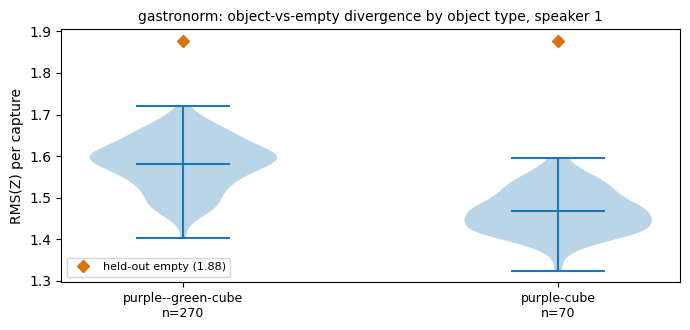

In [16]:
res_gastronorm = box_divergence("gastronorm")

  [plastic/two-cubes] 143x (2-obj) vs 5 empty  |  ratio=1.33  hi-band=3.10  frac>2s=28%  rawA=0.630


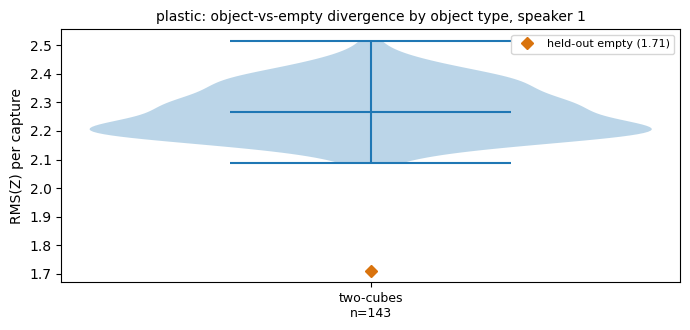

In [17]:
res_plastic = box_divergence("plastic")

  [wood/two-cubes] 196x (2-obj) vs 5 empty  |  ratio=1.20  hi-band=1.58  frac>2s=25%  rawA=0.653
  [wood/one-cube] 35x (1-obj) vs 5 empty  |  ratio=1.13  hi-band=1.39  frac>2s=22%  rawA=0.620


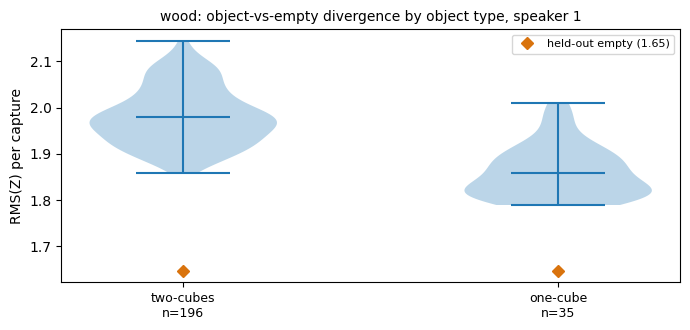

In [18]:
res_wood = box_divergence("wood")

  [cardboard/two-cubes] 118x (2-obj) vs 5 empty  |  ratio=2.32  hi-band=6.15  frac>2s=52%  rawA=0.550


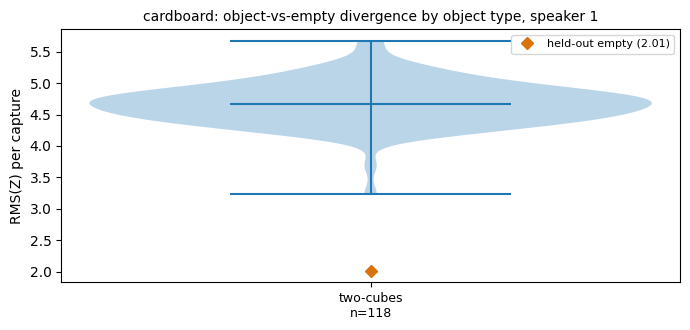

In [19]:
res_cardboard = box_divergence("cardboard")

  [shoebox/ring] 130x (1-obj) vs 15 empty  |  ratio=1.04  hi-band=1.03  frac>2s=26%  rawA=0.891
  [shoebox/cylinder] 123x (1-obj) vs 15 empty  |  ratio=1.12  hi-band=1.05  frac>2s=28%  rawA=0.940
  [shoebox/cube] 121x (1-obj) vs 15 empty  |  ratio=1.02  hi-band=0.99  frac>2s=25%  rawA=0.882
  [shoebox/mug] 101x (1-obj) vs 15 empty  |  ratio=0.95  hi-band=0.93  frac>2s=24%  rawA=0.812


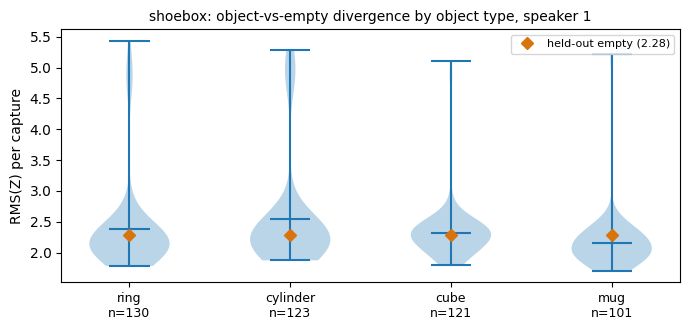

In [20]:
res_shoebox = box_divergence("shoebox")

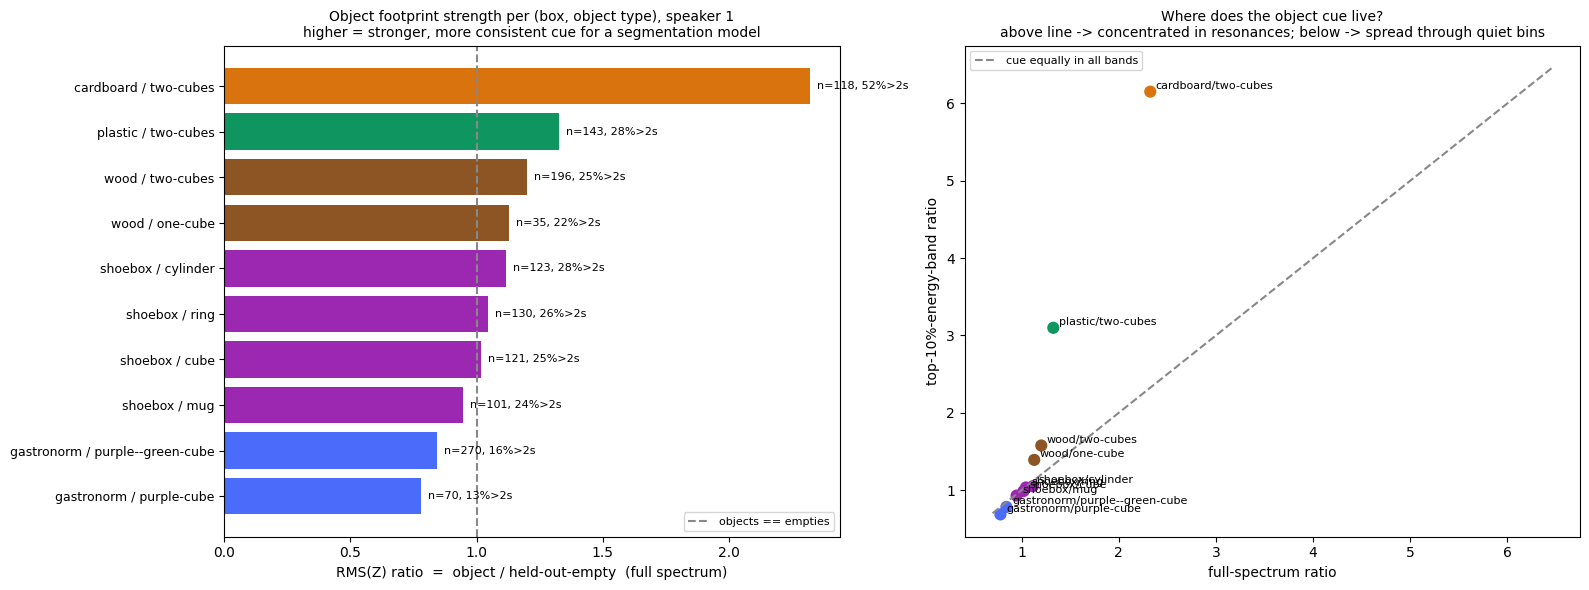

,box,object,n_objects,n_samples,n_empty,rmsz_ratio,ratio_hi,frac_sig,frac_sig_hi,mean_rawA
0,cardboard,two-cubes,2,118,5,2.323654,6.152101,0.516589,0.568999,0.549602
1,plastic,two-cubes,2,143,5,1.325391,3.098356,0.281955,0.278283,0.630197
2,wood,two-cubes,2,196,5,1.201750,1.576351,0.245973,0.242402,0.653336
3,wood,one-cube,1,35,5,1.128941,1.390322,0.216311,0.188882,0.619976
4,shoebox,cylinder,1,123,15,1.115067,1.050074,0.282576,0.295182,0.940209
5,shoebox,ring,1,130,15,1.044090,1.033737,0.264794,0.300917,0.890728
6,shoebox,cube,1,121,15,1.019242,0.987411,0.252919,0.271999,0.881678
7,shoebox,mug,1,101,15,0.947525,0.928633,0.237496,0.232329,0.811931
8,gastronorm,purple--green-cube,2,270,6,0.842597,0.781978,0.159313,0.178781,0.618660
9,gastronorm,purple-cube,1,70,6,0.781300,0.685443,0.133802,0.133652,0.590719


In [21]:
# ---- combined view: every (box, object type) ----------------------
rows = [r for lst in (res_gastronorm, res_plastic, res_wood, res_cardboard, res_shoebox) for r in lst]
summary = (pd.DataFrame(rows)[["box", "object", "n_objects", "n_samples", "n_empty",
                               "rmsz_ratio", "ratio_hi", "frac_sig", "frac_sig_hi", "mean_rawA"]]
           .sort_values("rmsz_ratio", ascending=False).reset_index(drop=True))

BOX_COLOR = {"gastronorm": "#4b6bfb", "plastic": "#0f9660", "wood": "#8d5524",
             "cardboard": "#d9730d", "shoebox": "#9c27b0"}
labels = [f"{r.box} / {r.object}" for r in summary.itertuples()]
colors = [BOX_COLOR[b] for b in summary["box"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y = np.arange(len(summary))
axes[0].barh(y, summary["rmsz_ratio"], color=colors)
axes[0].axvline(1.0, color="#888", ls="--", label="objects == empties")
axes[0].set_yticks(y); axes[0].set_yticklabels(labels, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("RMS(Z) ratio  =  object / held-out-empty  (full spectrum)")
axes[0].set_title(f"Object footprint strength per (box, object type), speaker {SPEAKER}\n"
                  "higher = stronger, more consistent cue for a segmentation model", fontsize=10)
axes[0].legend(fontsize=8)
for i, r in enumerate(summary.itertuples()):
    axes[0].text(r.rmsz_ratio, i, f"  n={r.n_samples}, {r.frac_sig:.0%}>2s", va="center", fontsize=8)

axes[1].scatter(summary["rmsz_ratio"], summary["ratio_hi"], c=colors, s=60)
lo, hi = 0.7, max(summary["rmsz_ratio"].max(), summary["ratio_hi"].max()) * 1.05
axes[1].plot([lo, hi], [lo, hi], color="#888", ls="--", label="cue equally in all bands")
for r in summary.itertuples():
    axes[1].annotate(f"{r.box}/{r.object}", (r.rmsz_ratio, r.ratio_hi), fontsize=8,
                     xytext=(4, 2), textcoords="offset points")
axes[1].set_xlabel("full-spectrum ratio")
axes[1].set_ylabel(f"top-{HI_ENERGY_FRAC:.0%}-energy-band ratio")
axes[1].set_title("Where does the object cue live?\nabove line -> concentrated in resonances; below -> spread through quiet bins",
                  fontsize=10)
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()
summary

### Reading this

- **`rmsz_ratio` (left bars, sort order)** is the headline: for that (box, object
  type), a capture with the object deviates from the empty-box mean `ratio`&times; as
  much as a *held-out empty capture* does. `ratio ≈ 1` ⇒ the object is almost
  invisible in the spectrum (little for a model to learn); `ratio ≫ 1` ⇒ a strong,
  consistent acoustic footprint ⇒ higher segmentation ceiling. Compare this ordering
  against the boxes'/objects' actual eval IoU / localization.
- **Per-box violins (the five cells above)** show the per-capture `RMS(Z)` spread for
  each object type against that box's held-out-empty baseline (orange diamond). High
  *and tight* above the diamond is the good case; high but wide ⇒ the cue swings a lot
  by position; sitting on the diamond ⇒ the object barely moves the spectrum.
- **Full vs high-energy band (right scatter).** Points **above** the diagonal ⇒ the
  object cue is concentrated in the loud resonances, so a band-limited FFT input would
  keep most of it. **Below** ⇒ the discriminative information is spread through the
  quiet bins and cropping frequencies would throw signal away.
- **`frac_sig`** (annotated) is the fraction of `(laser, freq, x/y)` bins past 2σ —
  how *distributed* the cue is: tiny ⇒ needle in a haystack, large ⇒ signal everywhere.
- **`mean_rawA`** in the table is metric A (raw RMS Δ log-magnitude). A row with large
  `rawA` but modest `ratio` is loud but noisy — raw change overstates learnability.

Caveats:
- **Object count differs.** `two-cubes` rows carry a mechanically larger footprint
  than `one-cube` / `ring` / `mug` rows — compare within the same `n_objects` first.
  gastronorm's own `purple-cube` (1) vs `purple--green-cube` (2) shows the size effect
  inside one box.
- **Few empties.** σ is a MAD estimate from only `N_REF_EMPTY=5` empties (bootstrapped
  where more exist), so absolute `RMS(Z)` is biased high; the object/empty *ratio*
  cancels most of that, but treat gaps under ~10% as noise.
- Ignores mask-resolution / box-size / position-count / laser-grid confounds from the
  section intro. First-order explanation, not the last word.